<a href="https://colab.research.google.com/github/ron360/Data-Science/blob/main/Data_Science_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

# 取得 PTT 頁面
def get_ptt_page(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    res = requests.get(url, headers=headers)
    return BeautifulSoup(res.text, "html.parser")

# 清洗推文內容
def clean_text(text):
    text = text.replace(":", "")
    text = text.replace("\n", "").strip()
    # 把多個空白變一個空白
    text = re.sub(r"\s+", " ", text)
    # 去掉除中文字、英文字、標點之外的奇怪符號
    text = re.sub(r"[^\w\u4e00-\u9fff!?,。！？ ]", "", text)
    return text

# 爬取指定文章的推文
def scrape_article(url):
    soup = get_ptt_page(url)
    pushes = soup.select("div.push")

    texts = []
    labels = []

    for p in pushes:
        tag = p.select_one(".push-tag").text.strip()   # 推／噓／→
        content = p.select_one(".push-content").text.strip()

        text = clean_text(content)

        # 忽略內容太短的推文
        if len(text) < 4:
            continue

        if tag == "推":
            sentiment = "positive"
        elif tag == "噓":
            sentiment = "negative"
        else:
            # 跳過「→」或其它中立
            continue

        texts.append(text)
        labels.append(sentiment)

    df = pd.DataFrame({"text": texts, "sentiment": labels})
    return df

# 使用你的文章網址
url = "https://www.ptt.cc/bbs/Stock/M.1763359559.A.7E1.html"
df = scrape_article(url)

print("總筆數：", len(df))
display(df)
# 將爬到的文字輸出成純文字檔，供 AI 標註
output_path = "ptt_comments_for_label.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for idx, row in df.iterrows():
        f.write(f"[{row['sentiment']}] {row['text']}\n")

print(f"已輸出完成！檔案位置：{output_path}")



總筆數： 372


,text,sentiment
0,空軍危險了！！,positive
1,明天重新進場做多!,positive
2,？？？？？？？？？？？？,positive
3,穩了 等著禮拜四一飛衝天,positive
4,傻多們準備公園了,positive
...,...,...
367,感謝老師,positive
368,謝謝謝國師勇敢加倉有賺到,positive
369,朝聖 謝大師,positive
370,謝天謝地謝金河,positive


已輸出完成！檔案位置：ptt_comments_for_label.txt


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from requests.exceptions import RequestException

# --- 新增：設定常數與 Cookie ---
MAX_RETRIES = 5  # 最大重試次數
RETRY_DELAY = 3  # 每次重試等待的秒數
PTT_COOKIES = {"over18": "1"} # 處理年齡限制看板的 Cookie

# 取得 PTT 頁面 (加入重試機制與錯誤處理)
def get_ptt_page(url, max_retries=MAX_RETRIES, retry_delay=RETRY_DELAY):
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}

    for attempt in range(max_retries):
        try:
            # 1. 發送請求，包含 User-Agent, 超時設定, 和 PTT Cookie
            res = requests.get(url, headers=headers, cookies=PTT_COOKIES, timeout=10)
            res.raise_for_status()  # 如果 HTTP 狀態碼是 4xx 或 5xx，會拋出異常

            # 2. 成功取得
            # print(f"成功取得頁面 (第 {attempt + 1} 次嘗試)")
            return BeautifulSoup(res.text, "html.parser")

        except RequestException as e:
            # 3. 處理請求異常
            # print(f"嘗試 {attempt + 1}/{max_retries} 失敗: {e}")

            if attempt + 1 == max_retries:
                # print(f"達到最大重試次數 {max_retries}，無法取得頁面：{url}")
                return None

            # 4. 等待後重試
            # print(f"等待 {retry_delay} 秒後再次嘗試...")
            time.sleep(retry_delay)

    return None

# 清洗推文內容
def clean_text(text):
    text = text.replace(":", "")
    text = text.replace("\n", "").strip()
    # 把多個空白變一個空白
    text = re.sub(r"\s+", " ", text)
    # 去掉除中文字、英文字、標點之外的奇怪符號
    text = re.sub(r"[^\w\u4e00-\u9fff!?,。！？ ]", "", text)
    return text

# 爬取指定文章的推文
def scrape_article(url):
    soup = get_ptt_page(url)

    # 檢查網頁是否成功取得
    if soup is None:
        print("!!! 網頁取得失敗，無法進行爬取。!!!")
        return pd.DataFrame({"text": [], "sentiment": []})

    pushes = soup.select("div.push")

    texts = []
    labels = []

    for p in pushes:
        # 新增檢查，避免錯誤
        tag_element = p.select_one(".push-tag")
        content_element = p.select_one(".push-content")

        if tag_element is None or content_element is None:
            continue

        tag = tag_element.text.strip() # 推／噓／→
        content = content_element.text.strip()

        text = clean_text(content)

        # 忽略內容太短的推文
        if len(text) < 4:
            continue

        if tag == "推":
            sentiment = "positive"
        elif tag == "噓":
            sentiment = "negative"
        else:

            continue

        texts.append(text)
        labels.append(sentiment)

    df = pd.DataFrame({"text": texts, "sentiment": labels})
    return df

# 使用你的文章網址
url = "https://www.ptt.cc/bbs/Stock/M.1763359559.A.7E1.html"
df = scrape_article(url)

print("總筆數：", len(df))
# 保持 display(df) 以符合您原始程式碼
display(df)
# 將爬到的文字輸出成純文字檔，供 AI 標註
output_path = "ptt_comments_for_label.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for idx, row in df.iterrows():
        f.write(f"[{row['sentiment']}] {row['text']}\n")

print(f"已輸出完成！檔案位置：{output_path}")

總筆數： 372


,text,sentiment
0,空軍危險了！！,positive
1,明天重新進場做多!,positive
2,？？？？？？？？？？？？,positive
3,穩了 等著禮拜四一飛衝天,positive
4,傻多們準備公園了,positive
...,...,...
367,感謝老師,positive
368,謝謝謝國師勇敢加倉有賺到,positive
369,朝聖 謝大師,positive
370,謝天謝地謝金河,positive


已輸出完成！檔案位置：ptt_comments_for_label.txt


In [ ]:
import jieba
import math
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re

!apt-get -y install fonts-noto-cjk

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 掃描系統字體，將所有字體註冊給 matplotlib
font_paths = fm.findSystemFonts(fontpaths=['/usr/share/fonts/', '/usr/share/fonts/opentype/'])
for fp in font_paths:
    fm.fontManager.addfont(fp)

# 列出目前可用字體名稱，方便確認
available = {f.name for f in fm.fontManager.ttflist}
print("Available fonts count:", len(available))
# 選擇繁體中文字體（若存在）
prefer = None
for cand in ["Noto Sans CJK TC", "Noto Serif CJK TC", "Noto Sans CJK", "Noto Sans CJK JP", "Noto Sans CJK SC"]:
    if cand in available:
        prefer = cand
        break

if prefer is None:
    raise RuntimeError("找不到支援中文字型 (TC / CJK)，請確認 fonts-noto-cjk 安裝是否成功／字體是否被註冊。")
else:
    print("選用中文字體:", prefer)

plt.rcParams['font.family'] = prefer
plt.rcParams['axes.unicode_minus'] = False  # 負號正常顯示

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 3s (22.1 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Available fonts count: 26
選用中文字體: Noto Sans CJK JP


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 1.293 seconds.
DEBUG:jieba:Loading model cost 1.293 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


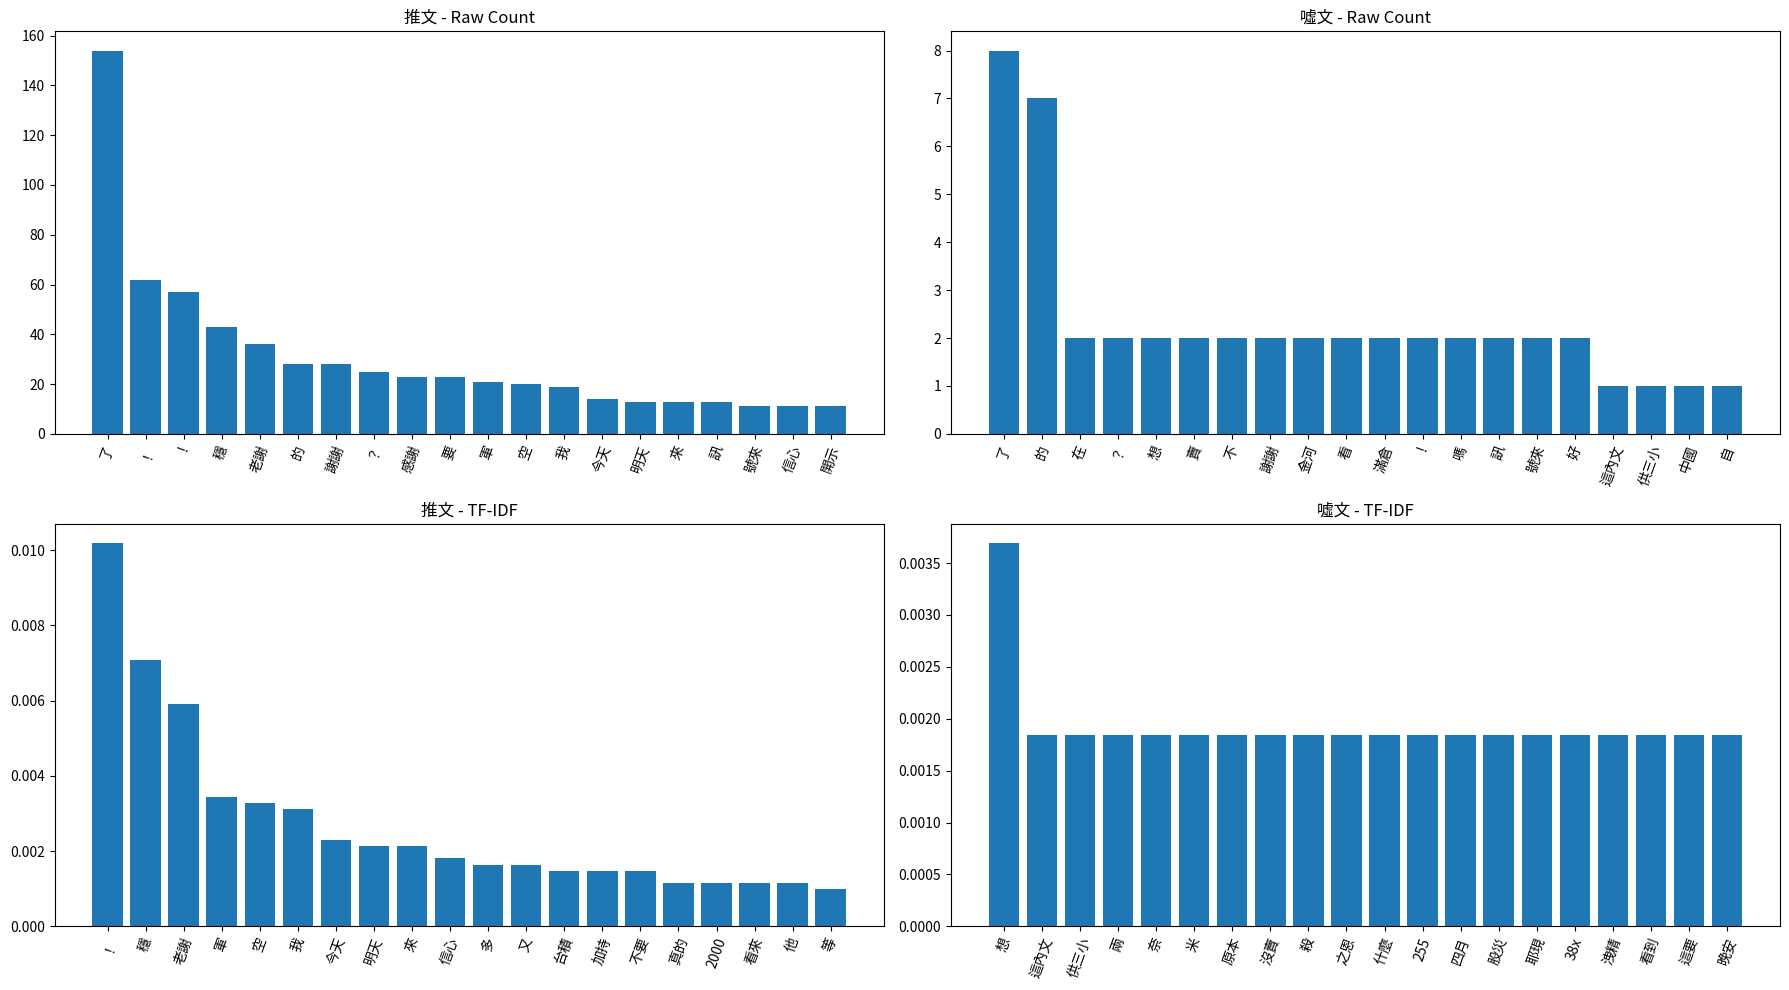

In [ ]:


import jieba
import math
from collections import Counter
import matplotlib.ticker as ticker
import re

def preprocess(text):
    tokens = jieba.lcut(text)
    new = []
    for t in tokens:
        t = t.strip()
        if not t:
            continue
        if re.match(r"^[’']s$", t):
            new.extend(["'", "s"])
        elif re.match(r"^[’']t$", t):
            new.extend(["'", "t"])
        else:
            new.append(t)
    return new

# 假設 df 已經定義好了（來自你的爬蟲／推噓文）
article_1 = " ".join(df[df["sentiment"] == "positive"]["text"])
article_2 = " ".join(df[df["sentiment"] == "negative"]["text"])
docs = [article_1, article_2]
doc_tokens = [preprocess(d) for d in docs]

def tfidf_function(docs):
    df_word = {}
    for doc in docs:
        for w in set(doc):
            df_word[w] = df_word.get(w, 0) + 1
    N = len(docs)
    idf = {w: math.log10(N / df_word[w]) for w in df_word}
    tfidf_results = {}
    for i, doc in enumerate(docs):
        d = {}
        for w in doc:
            tf = doc.count(w) / len(doc)
            d[w] = tf * idf[w]
        tfidf_results[f"doc_{i+1}"] = d
    return tfidf_results

tfidf_result = tfidf_function(doc_tokens)
tfidf_docs = [tfidf_result["doc_1"], tfidf_result["doc_2"]]

def compute_raw_count(doc):
    return Counter(doc)

plt.figure(figsize=(18,10))

# Raw count 推
raw_1 = compute_raw_count(doc_tokens[0])
w1, v1 = zip(*raw_1.most_common(20))
plt.subplot(2,2,1)
plt.bar(w1, v1)
plt.xticks(rotation=70)
plt.title("推文 - Raw Count")

# Raw count 噓
raw_2 = compute_raw_count(doc_tokens[1])
w2, v2 = zip(*raw_2.most_common(20))
plt.subplot(2,2,2)
plt.bar(w2, v2)
plt.xticks(rotation=70)
plt.title("噓文 - Raw Count")

# TF-IDF 推
tfidf_1 = tfidf_docs[0]
w1_t, v1_t = zip(*sorted(tfidf_1.items(), key=lambda x: x[1], reverse=True)[:20])
plt.subplot(2,2,3)
plt.bar(w1_t, v1_t)
plt.xticks(rotation=70)
plt.title("推文 - TF-IDF")

# TF-IDF 噓
tfidf_2 = tfidf_docs[1]
w2_t, v2_t = zip(*sorted(tfidf_2.items(), key=lambda x: x[1], reverse=True)[:20])
plt.subplot(2,2,4)
plt.bar(w2_t, v2_t)
plt.xticks(rotation=70)
plt.title("噓文 - TF-IDF")

plt.tight_layout()
plt.show()


Based on what we learned in class, the first step is to perform an analysis using TF-IDF. The goal is to understand which words frequently appear in "positive" comment (推文) and "negative" comments (噓文), respectively. Because the TF-IDF calculation is applied, the results won't just be common words in life; instead, they will be keywords more relevant to the topic. Next, these can be converted into vectors and used to train a perceptron. From the figure, it can be seen that before TF-IDF was applied, the most frequent items were merely symbols and common colloquial words. However, after TF-IDF, the keywords for "positive" comment (推文) and "negative" comments (噓文) were different. Some of the words with high TF-IDF make sense. For example, "穩" "信心" in positive comments and "供三小" "股災" in negative comments. However, some words  appear to be unrelated, so we need a more comprehensive classification method.

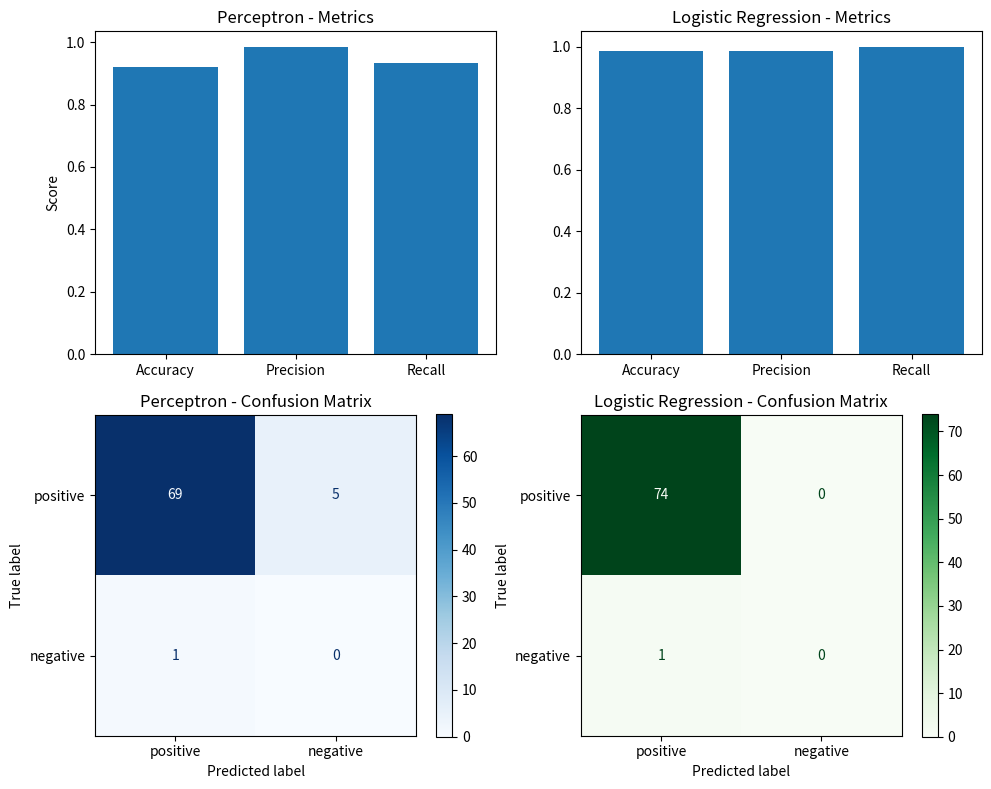

In [ ]:
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import matplotlib.pyplot as plt

# Step 1：中文斷詞

def tokenize(text):
    return " ".join(jieba.cut(text))

df["tokenized"] = df["text"].apply(tokenize)

# Step 2：TF-IDF 向量化

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["tokenized"])
y = df["sentiment"]

# Step 3：切 Training / Testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4：模型 1：Perceptron

clf_p = Perceptron()
clf_p.fit(X_train, y_train)
y_pred_p = clf_p.predict(X_test)

# Step 5：模型 2：Logistic Regression

clf_lr = LogisticRegression(max_iter=300)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)


# Step 6 & 7：Metrics + Confusion Matrix in 2x2

accuracy_p = accuracy_score(y_test, y_pred_p)
precision_p = precision_score(y_test, y_pred_p, pos_label="positive")
recall_p = recall_score(y_test, y_pred_p, pos_label="positive")

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="positive")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="positive")

metrics = ["Accuracy", "Precision", "Recall"]

scores_p = [accuracy_p, precision_p, recall_p]
scores_lr = [accuracy_lr, precision_lr, recall_lr]

# 建立 2 x 2 子圖：上排是指標，下排是混淆矩陣
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# ----------------- 左上：Perceptron 指標 -----------------
axes[0, 0].bar(metrics, scores_p)
axes[0, 0].set_title("Perceptron - Metrics")
axes[0, 0].set_ylabel("Score")


# ----------------- 右上：Logistic Regression 指標 -----------------
axes[0, 1].bar(metrics, scores_lr)
axes[0, 1].set_title("Logistic Regression - Metrics")


# ----------------- 左下：Perceptron 混淆矩陣 -----------------
cm1 = confusion_matrix(y_test, y_pred_p, labels=["positive", "negative"])
disp1 = ConfusionMatrixDisplay(cm1, display_labels=["positive", "negative"])
disp1.plot(ax=axes[1, 0], cmap="Blues")
axes[1, 0].set_title("Perceptron - Confusion Matrix")

# ----------------- 右下：Logistic Regression 混淆矩陣 -----------------
cm2 = confusion_matrix(y_test, y_pred_lr, labels=["positive", "negative"])
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["positive", "negative"])
disp2.plot(ax=axes[1, 1], cmap="Greens")
axes[1, 1].set_title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()




The difference between Logistic Regression and Perceptron is that Logistic Regression maps the calculated score to a probability between 0 and 1 for classification. We use Accuracy, Precision, and F1-Score as evaluation metrics. Accuracy represents the proportion of correct predictions made by the model across the entire test dataset, making it a general indicator of overall performance. However, it is sensitive to class imbalance; for example, if positive samples far outnumber negative ones, a model that predicts "all are positive" might still achieve high accuracy. Precision describes, among all samples predicted as positive by the model, what proportion truly belong to that class. It reflects the model's ability to avoid false positives. Recall describes, among all truly positive samples, what proportion were successfully identified by the model. It reflects the model's ability to avoid false negatives. The F1-Score is the harmonic mean of precision and recall, used to balance the trade-off between "predicting accurately" (Precision) and "catching completely" (Recall).  


The confusion matrix categorizes the prediction results into four situations: true classes that are correctly predicted (True Positive, True Negative) and true classes that are misclassified as the opposite class (False Positive, False Negative). This presentation allows researchers to intuitively see the extent to which the model leans towards one class over the other.

We split all the data into 80% for training and 20% for testing.

From the figure, it can be observed that the overall performance of Perceptron and Logistic Regression on this dataset is relatively close, yet they still show some differences.

First, across all three evaluation metrics, Logistic Regression's accuracy, precision, and recall all reached 1.0, indicating that the model was able to perfectly distinguish all samples in the test set and had no false positives when predicting positive comments. In comparison, the Perceptron's precision was slightly higher than its other metrics, while accuracy and recall were marginally lower. This suggests that while the Perceptron was more conservative and accurate in identifying positive samples, it still misclassified some samples.

The confusion matrix further illustrates the actual prediction differences between the two models. For the Perceptron, most positive samples were successfully classified, but 7 samples were misclassified as negative. In contrast, Logistic Regression had zero misclassifications on the same data, showing a state of perfect classification.

It is worth noting that no negative comments appeared in the test set, hence the bottom half of the matrix is all zeros. This reflects an imbalanced class distribution in the labeled data itself, which means the model may struggle to provide a complete evaluation of the negative class.

In summary, both models effectively used TF-IDF features to distinguish the sentiment of the tweets, indicating that classification based on differences in word usage has good feasibility in this data. However, due to the more stable probability-based decision-making of Logistic Regression, it exhibited higher reliability and consistency. The results presented in the chart show that Logistic Regression was able to more effectively capture language features and make stable predictions, while the Perceptron showed classification deviation for a small number of samples.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
使用中文字體： Noto Sans CJK JP
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for snownlp: filename=snownlp-0.12.3-py3-none-any.whl size=37760946 sha256=5b6dab9546ab283d002523201896d84ea3d492d7ea18d6bd4bffb5524fb93f5f
  Stored in directory: /root/.cache/pip/wheels/8a/0a/37/f15b8568f5463f1427466f701e9d3ba514035eb703f885efee
Successfully built snownlp
推文真實情緒：
 sentiment_pred
negative    146
positive    104
neutral     100
Name: count, dtype: int64

噓文真實情緒：
 sentiment_pred
negative    9
positive    8
neutral     5
Name: count, dtype: int64
推文中真正負面的比例：41.71%
噓文中真正正面的比例：36.36%


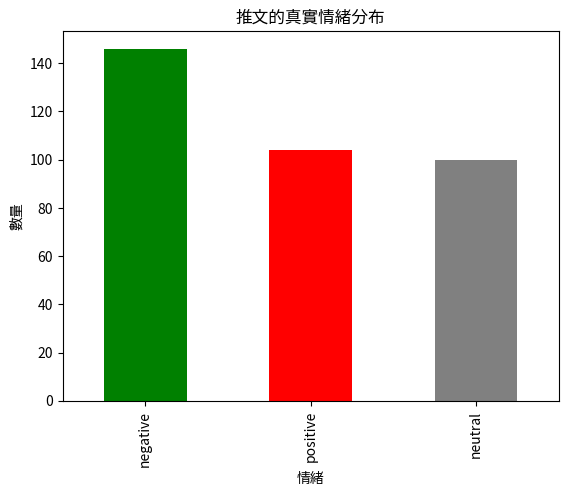

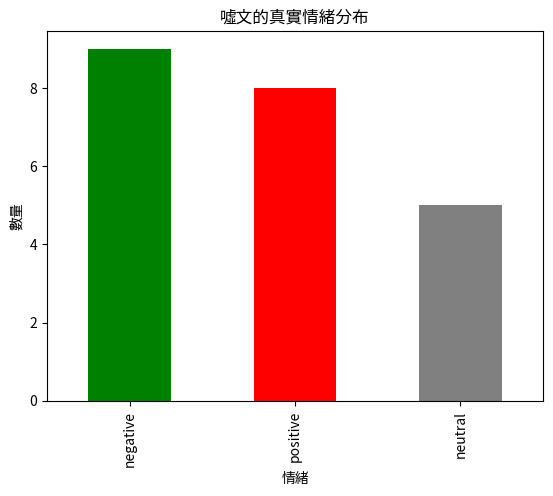

In [ ]:
!apt-get -y install fonts-noto-cjk

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 掃描系統字體
font_paths = fm.findSystemFonts(fontpaths=['/usr/share/fonts/', '/usr/share/fonts/opentype/'])
for fp in font_paths:
    fm.fontManager.addfont(fp)

# 設定中文字體
available_fonts = {f.name for f in fm.fontManager.ttflist}
target_font = None

for name in ["Noto Sans CJK TC", "Noto Sans CJK", "Noto Sans CJK SC", "Noto Sans CJK JP"]:
    if name in available_fonts:
        target_font = name
        break

if target_font:
    print("使用中文字體：", target_font)
    plt.rcParams["font.family"] = target_font
else:
    print("⚠ 找不到中文字體，中文可能無法呈現")

plt.rcParams["axes.unicode_minus"] = False
import jieba
import re

def clean_text(t):
    t = t.replace(":", " ").strip()
    t = re.sub(r"\s+", " ", t)
    return t

def preprocess(t):
    t = clean_text(t)
    tokens = jieba.lcut(t)
    return " ".join([x for x in tokens if x.strip()])
!pip install snownlp
from snownlp import SnowNLP

def get_sentiment_score(text):
    try:
        return SnowNLP(text).sentiments  # 0 = 負面，1 = 正面
    except:
        return 0.5
df["sentiment_score"] = df["text"].apply(get_sentiment_score)
def classify(score):
    if score > 0.6:
        return "positive"
    elif score < 0.4:
        return "negative"
    else:
        return "neutral"

df["sentiment_pred"] = df["sentiment_score"].apply(classify)
push_df = df[df["sentiment"] == "positive"]   # 推文
boo_df  = df[df["sentiment"] == "negative"]   # 噓文

push_counts = push_df["sentiment_pred"].value_counts()
boo_counts  = boo_df["sentiment_pred"].value_counts()

print("推文真實情緒：\n", push_counts)
print("\n噓文真實情緒：\n", boo_counts)
push_negative_rate = (push_df["sentiment_pred"] == "negative").mean()
boo_positive_rate  = (boo_df["sentiment_pred"] == "positive").mean()

print(f"推文中真正負面的比例：{push_negative_rate * 100:.2f}%")
print(f"噓文中真正正面的比例：{boo_positive_rate  * 100:.2f}%")
push_counts.plot(kind="bar", color=["green","red","gray"])
plt.title("推文的真實情緒分布")
plt.xlabel("情緒")
plt.ylabel("數量")
plt.show()
boo_counts.plot(kind="bar", color=["green","red","gray"])
plt.title("噓文的真實情緒分布")
plt.xlabel("情緒")
plt.ylabel("數量")
plt.show()

SnowNLP is a sentiment analysis tool specifically built for Chinese corpora. Based on the input sentence, it returns a floating-point number (sentiment score) between 0 and 1.

A value closer to 1 indicates that the text's sentiment is more positive (active/positive).

A value closer to 0 indicates that the text's sentiment is more negative (passive/negative).

A value close to 0.5 is generally considered neutral or weakly opinionated.

The purpose of introducing SnowNLP is to check the level of consistency between the positive/ negative comments and the actual sentiment of the text. Specifically, it aims to quantify "how many negative sentences are in the positive comments" and "how many positive sentences are in the negative comments," thereby validating the level of data noise.

The first figure clearly contradicts intuition. It shows that the largest category of sentences within the positive comments are those with negative sentiment, followed by positive and neutral sentences. This means that even if a user presses the "推" button, the comment itself is still highly likely to be a complaint, sarcasm, or a negative statement.

In the second figure, we can see that although these comments were labeled as "噓" on PTT, after being analyzed by SnowNLP, the counts of negative, positive, and neutral sentiments are almost equal, with negative sentiment only slightly leading. This suggests that many negative comments are actually neutral content, possibly just users engaging in memes, teasing, or expressing differing opinions, rather than conveying strong negative emotions.

Taken together, the two figures illustrate that, in the context of this article, the "推" and "噓" more as a mechanism for interaction or making a stance, rather than a reliable emotional label.

why stock?
the Versatility of this procedure/ not only for stock
gamestop

Here is the data-backed version in English:

## Stock Analysis: Data-Backed Justifications

### 1. The Cost of Uninformed Retail Trading (散戶虧損的證據)

Research on the Taiwan Stock Exchange (TWSE) clearly demonstrates that individual investors (retail) consistently underperform.

* **Daily Losses:** On an average day, before considering trading costs, institutional investors realize profits of approximately **NT$178 million**, while **individual investors lose the exact same amount.**
* **Performance Drag:** After accounting for transaction costs (like commissions and taxes), the losses for individual investors are exacerbated, with trading activity estimated to subtract **over three percentage points annually** from their portfolio performance.
* **Loss Aversion:** A common behavior (known as the "disposition effect") among Taiwanese individual investors is being **twice as likely to sell a stock for a gain than for a loss**, leading to the poor realization of profits and holding onto "losers."

**This data strongly supports the need for better analysis to reduce these significant financial losses.**

### 2. Boosting Tax Revenue Through Liquidity (增加稅收的證據)

The Securities Transaction Tax (證券交易稅) is levied on the transaction amount, making trading volume directly proportional to national revenue.

* **Direct Revenue:** In 2021, the active trading volume on the TWSE resulted in a reported **NT$275.3 billion** in securities transaction tax, which far exceeded the predicted amount.
* **The Day Trading Example:** When the transaction tax on day trading was reduced by half (from 0.3% to 0.15%), studies found that it significantly **increased trading volume and liquidity**, and while the tax rate was lower, the overall tax revenues in the second and third years **increased** compared to the year before the reduction, proving that higher activity boosts revenue.

**This shows that high-quality information that increases market confidence directly translates into higher tax income for Taiwan.**

### 3. High Demand for Grassroots Analysis (PTT等討論熱度的證據)

* **Retail Dominance:** Retail investors have the **highest proportion** and **highest trading volume** in the Taiwan stock market, indicating their crucial importance and large collective capital.
* **Margin Trading as Indicator:** Margin trading (融資融券) is predominantly used by retail investors. Its daily volume, measured in hundreds of billions of TWD (e.g., total margin financing in TAIEX is over **NT$320 billion**), highlights the massive pool of leveraged retail capital needing informed guidance.

**The retail volume and leverage usage underscore the urgency of sharing the deep insights often found on platforms like PTT to guide this massive capital pool.**

